# Analytics & Performance

This notebook reads timing logs and visualizes performance metrics across all modules.

## Learning Objectives

- Read and analyze timing logs
- Visualize performance trends
- Compare execution times across modules


Reading timing log: outputs/logs/timing_20251230_143542.csv

Timing Summary:
       duration     timestamp
count  2.000000  2.000000e+00
mean   0.005609  1.767105e+09
std    0.006405  1.360263e+01
min    0.001080  1.767105e+09
25%    0.003345  1.767105e+09
50%    0.005609  1.767105e+09
75%    0.007874  1.767105e+09
max    0.010138  1.767105e+09


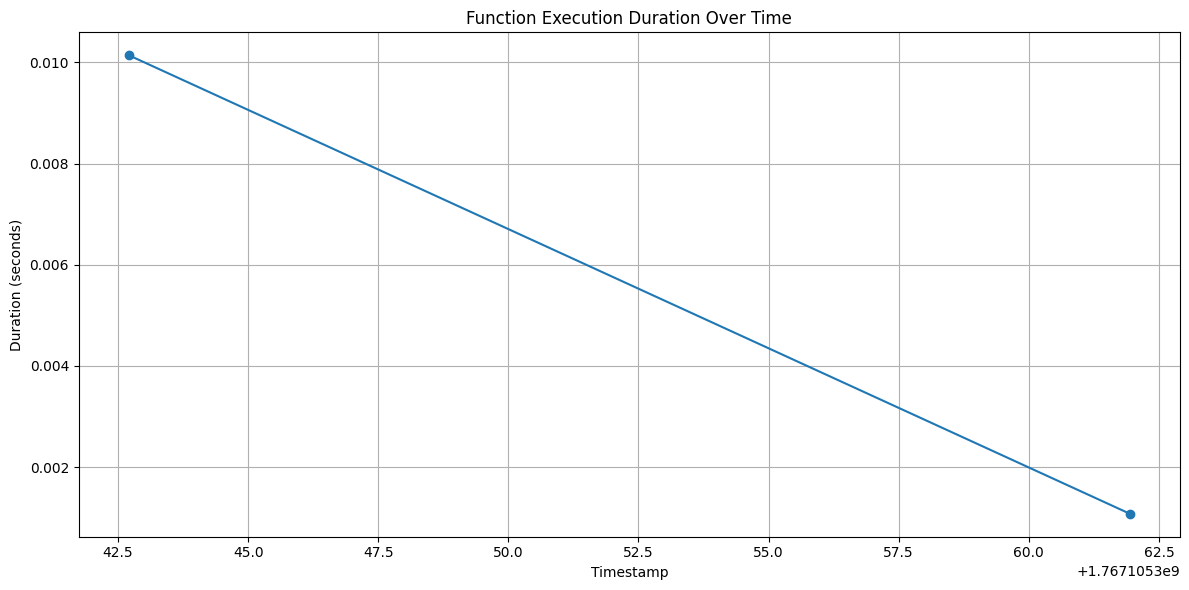


Performance by Function:
                       mean  std  count
function                               
example_operation  0.001080  NaN      1
slow_function      0.010138  NaN      1


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import os

# Find all timing log files
log_files = glob.glob("outputs/logs/timing_*.csv")

if log_files:
    # Read the most recent log file (using os.path.getmtime)
    latest_log = max(log_files, key=os.path.getmtime)
    print(f"Reading timing log: {latest_log}")
    
    # Read CSV
    try:
        logs = pd.read_csv(latest_log, names=['function', 'duration', 'timestamp'])
        
        print("\nTiming Summary:")
        print(logs.describe())
        
        # Plot execution times
        plt.figure(figsize=(12, 6))
        plt.plot(logs['timestamp'], logs['duration'], marker='o')
        plt.xlabel('Timestamp')
        plt.ylabel('Duration (seconds)')
        plt.title('Function Execution Duration Over Time')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # Group by function
        if len(logs) > 0:
            grouped = logs.groupby('function')['duration'].agg(['mean', 'std', 'count'])
            print("\nPerformance by Function:")
            print(grouped)
    except Exception as e:
        print(f"Error reading log file: {e}")
        print("Run some modules first to generate timing logs.")
else:
    print("No timing logs found. Run modules with @timeit decorator to generate logs.")
